CÀI ĐẶT MÔI TRƯỜNG

In [ ]:
!pip install torch torchvision timm opencv-python matplotlib albumentations
!pip install ultralytics
!pip install diffusers transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.2 MB/s eta 0:00:00


Load Dataset

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"tructuan","key":"768f4e18a9d36af3624304f90c336777"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:29<00:00, 259MB/s]
100% 2.29G/2.29G [00:29<00:00, 84.1MB/s]


In [ ]:
!unzip chest-xray-pneumonia.zip -d data/

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: data/chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: data/chest_xray/train/NORMAL/IM-0446-

In [ ]:
!kaggle datasets download -d vbookshelf/pneumothorax-chest-xray-images-and-masks

Dataset URL: https://www.kaggle.com/datasets/vbookshelf/pneumothorax-chest-xray-images-and-masks
License(s): unknown
100% 4.48G/4.50G [01:26<00:00, 88.3MB/s]
100% 4.50G/4.50G [01:26<00:00, 56.1MB/s]


In [ ]:
!mkdir -p data/pneumothorax
!unzip -q pneumothorax-chest-xray-images-and-masks.zip -d data/pneumothorax

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("data/chest_xray/train", transform=transform)
val_dataset   = datasets.ImageFolder("data/chest_xray/val", transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)

print("Classes:", train_dataset.classes)

Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,128,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128*28*28,256)
        self.fc2 = nn.Linear(256,num_classes)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model_cnn = CNNClassifier().to(device)

In [ ]:
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(5):
    model_cnn.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.2725282367718823
Epoch 2, Loss: 0.11510691580654013
Epoch 3, Loss: 0.07880814336354565
Epoch 4, Loss: 0.06945343468119705
Epoch 5, Loss: 0.05263582163881739


In [ ]:
import timm

model_vit = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
import os
import cv2
from torch.utils.data import Dataset
import numpy as np

class PneumoDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(img_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = cv2.imread(img_path)
        image = cv2.resize(image,(256,256))
        image = image / 255.0

        mask = cv2.imread(mask_path,0)
        mask = cv2.resize(mask,(256,256))
        mask = np.expand_dims(mask,0)/255.0

        return torch.tensor(image).permute(2,0,1).float(), torch.tensor(mask).float()

dataset_seg = PneumoDataset(
    "data/pneumothorax/siim-acr-pneumothorax/png_images",
    "data/pneumothorax/siim-acr-pneumothorax/png_masks"
)

loader_seg = DataLoader(dataset_seg, batch_size=8, shuffle=True)

In [ ]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(3,64,3,padding=1)
        self.enc2 = nn.Conv2d(64,128,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)

        self.up = nn.ConvTranspose2d(128,64,2,stride=2)
        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):
        x1 = torch.relu(self.enc1(x))
        x2 = self.pool(x1)
        x3 = torch.relu(self.enc2(x2))
        x4 = self.up(x3)
        return self.out(x4)

In [ ]:
loader_seg = DataLoader(
    dataset_seg,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

Epoch: 1 Loss: 0.040891614458573165
Epoch: 2 Loss: 0.01978807779249165
Epoch: 3 Loss: 0.01954334926277283
Epoch: 4 Loss: 0.019362905271834315
Epoch: 5 Loss: 0.019161475041589316


In [ ]:
model_unet = UNet().to(device)

optimizer = torch.optim.Adam(model_unet.parameters(), lr=1e-4)
criterion = torch.nn.BCEWithLogitsLoss()

In [ ]:
from tqdm import tqdm

scaler = torch.cuda.amp.GradScaler()

for epoch in range(5):
    model_unet.train()
    total_loss = 0

    loop = tqdm(loader_seg)

    for imgs, masks in loop:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model_unet(imgs)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Average Loss: {total_loss/len(loader_seg):.4f}")

/tmp/ipython-input-3550041335.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
  0%|          | 0/1506 [00:00<?, ?it/s]/tmp/ipython-input-3550041335.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 1506/1506 [04:16<00:00,  5.86it/s, loss=0.693]


Epoch 1 Average Loss: 0.7031


Epoch 2: 100%|██████████| 1506/1506 [04:17<00:00,  5.84it/s, loss=0.693]


Epoch 2 Average Loss: 0.6932


Epoch 3: 100%|██████████| 1506/1506 [04:16<00:00,  5.88it/s, loss=0.693]


Epoch 3 Average Loss: 0.6931


Epoch 4: 100%|██████████| 1506/1506 [04:17<00:00,  5.86it/s, loss=0.693]


Epoch 4 Average Loss: 0.6931


Epoch 5: 100%|██████████| 1506/1506 [04:18<00:00,  5.83it/s, loss=0.693]

Epoch 5 Average Loss: 0.6931


In [ ]:
class PneumoDetectionDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = []
        for img in os.listdir(img_dir):
            mask = cv2.imread(os.path.join(mask_dir, img),0)
            if np.any(mask > 0):
                self.images.append(img)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (512,512))
        image = torch.tensor(image/255.0).permute(2,0,1).float()

        mask = cv2.imread(mask_path, 0)
        mask = cv2.resize(mask,(512,512))

        ys, xs = np.where(mask > 0)

        if len(xs) > 0:
            x_min, x_max = xs.min(), xs.max()
            y_min, y_max = ys.min(), ys.max()
            boxes = torch.tensor([[x_min, y_min, x_max, y_max]], dtype=torch.float32)
            labels = torch.ones((1,), dtype=torch.int64)
        else:
            # QUAN TRỌNG: format rỗng đúng chuẩn
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        return image, target

In [ ]:
import torchvision

model_det = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = 2  # background + pneumothorax
in_features = model_det.roi_heads.box_predictor.cls_score.in_features
model_det.roi_heads.box_predictor = \
torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)

model_det = model_det.to(device)

In [ ]:
from torch.utils.data import DataLoader

dataset_det = PneumoDetectionDataset(
    "data/pneumothorax/siim-acr-pneumothorax/png_images",
    "data/pneumothorax/siim-acr-pneumothorax/png_masks"
)

loader_det = DataLoader(
    dataset_det,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

optimizer = torch.optim.Adam(model_det.parameters(), lr=1e-4)

for epoch in range(3):
    model_det.train()
    total_loss = 0

    for images, targets in loader_det:
        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model_det(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Detection Loss: {total_loss/len(loader_det):.4f}")

Epoch 1 Detection Loss: 0.1926
Epoch 2 Detection Loss: 0.1786
Epoch 3 Detection Loss: 0.1765


In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1,32,3,stride=2,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.decoder(self.encoder(x))

In [ ]:
model_ae = AutoEncoder().to(device)
optimizer = torch.optim.Adam(model_ae.parameters(), lr=1e-4)
criterion = nn.MSELoss()

for epoch in range(5):
    total_loss = 0
    for imgs, _ in loader_seg:
        imgs = imgs[:,0:1,:,:].to(device)  # convert to 1 channel

        outputs = model_ae(imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("AE Epoch:", epoch+1, "Loss:", total_loss/len(loader_seg))

AE Epoch: 1 Loss: 0.004719679446951709
AE Epoch: 2 Loss: 0.0005033254313977141
AE Epoch: 3 Loss: 0.00033718034070650556
AE Epoch: 4 Loss: 0.000251201795161741
AE Epoch: 5 Loss: 0.00020275348884307538


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100,256,4,1,0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,1,4,2,1),
            nn.Tanh()
        )

    def forward(self,z):
        return self.net(z)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,128,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256,1,4,1,0),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

In [ ]:
from diffusers import DDPMPipeline

pipeline = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
pipeline = pipeline.to(device)

image = pipeline().images[0]
image.save("generated.png")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1000 [00:00<?, ?it/s]

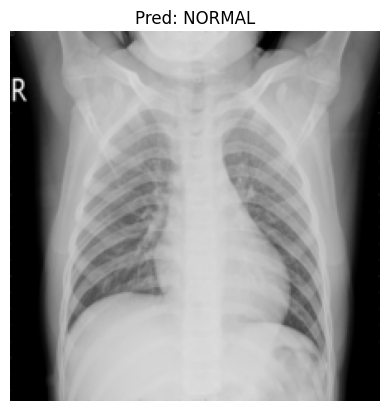

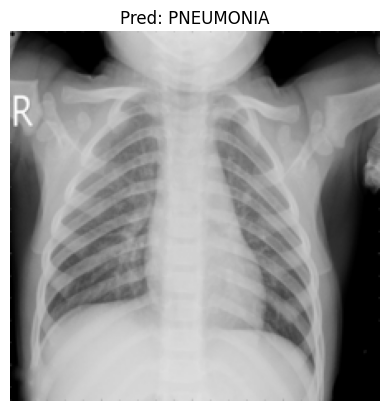

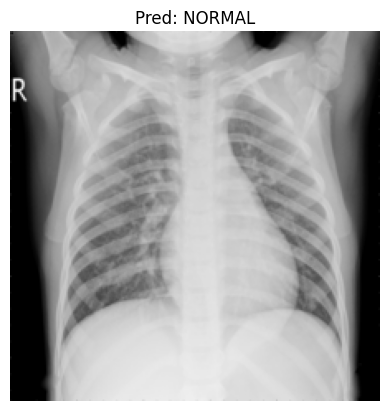

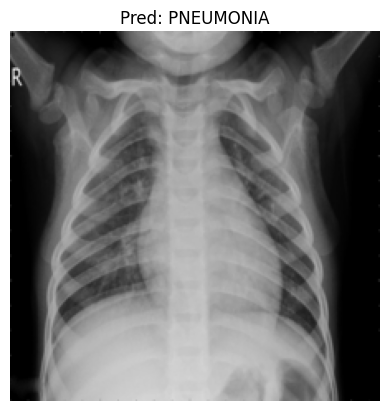

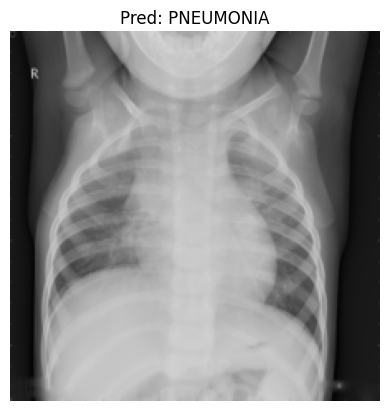

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

model_cnn.eval()

images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model_cnn(images)
    preds = torch.argmax(outputs, dim=1)

# Hiển thị 5 ảnh đầu
for i in range(5):
    img = images[i].cpu().permute(1,2,0)
    plt.imshow(img)
    plt.title(f"Pred: {train_dataset.classes[preds[i]]}")
    plt.axis("off")
    plt.show()

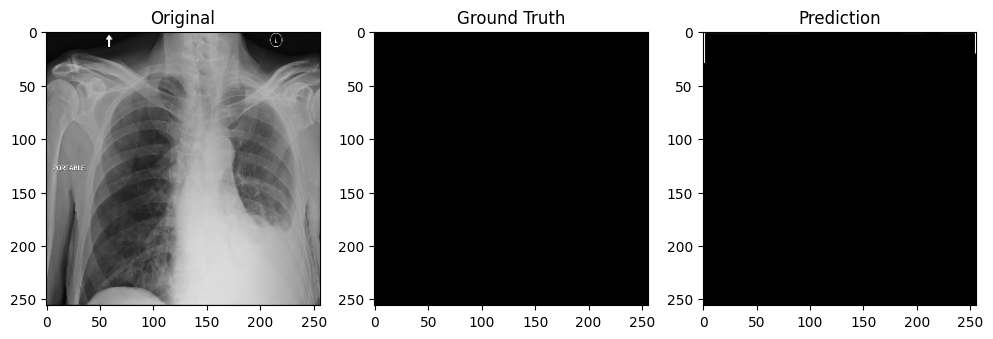

In [ ]:
model_unet.eval()

imgs, masks = next(iter(loader_seg))
imgs = imgs.to(device)

with torch.no_grad():
    outputs = model_unet(imgs)
    preds = torch.sigmoid(outputs)

# Show 1 example
img = imgs[0].cpu().permute(1,2,0)
mask_true = masks[0][0]
mask_pred = preds[0][0].cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask_true, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(mask_pred > 0.5, cmap="gray")
plt.title("Prediction")

plt.show()

In [ ]:
print(mask_true.unique())
print(mask_true.sum())

tensor([0.])
tensor(0.)


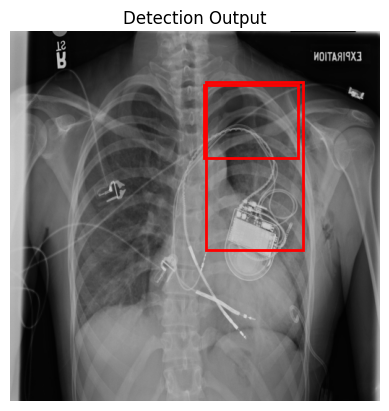

In [ ]:
model_det.eval()

img, target = dataset_det[0]
img_input = img.to(device)

with torch.no_grad():
    prediction = model_det([img_input])

boxes = prediction[0]['boxes'].cpu().numpy()
scores = prediction[0]['scores'].cpu().numpy()

img_np = img.permute(1,2,0).numpy()

plt.imshow(img_np)
for box, score in zip(boxes, scores):
    if score > 0.5:
        x1,y1,x2,y2 = box
        plt.gca().add_patch(
            plt.Rectangle((x1,y1), x2-x1, y2-y1,
                          fill=False, edgecolor='red', linewidth=2)
        )

plt.title("Detection Output")
plt.axis("off")
plt.show()

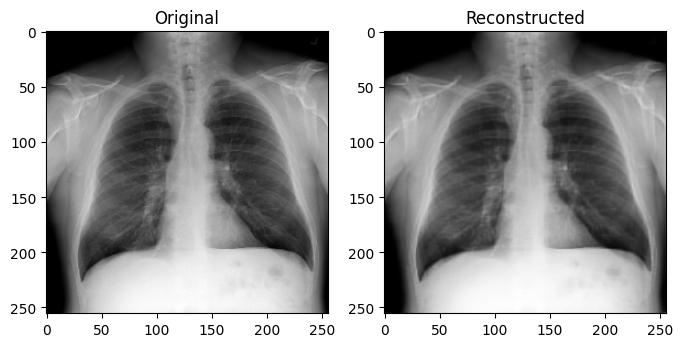

In [ ]:
model_ae.eval()

imgs, _ = next(iter(loader_seg))
imgs = imgs[:,0:1,:,:].to(device)

with torch.no_grad():
    reconstructed = model_ae(imgs)

orig = imgs[0][0].cpu()
recon = reconstructed[0][0].cpu()

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(orig, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(recon, cmap="gray")
plt.title("Reconstructed")

plt.show()

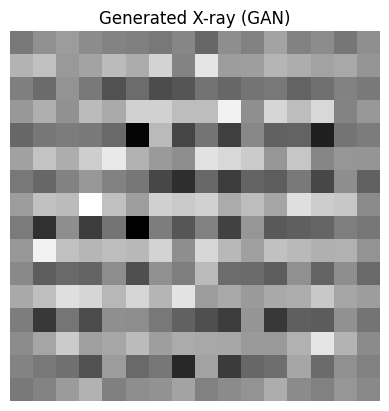

In [ ]:
import matplotlib.pyplot as plt

generator.eval()

noise = torch.randn(1,100,1,1).to(device)

with torch.no_grad():
    fake_img = generator(noise)

img = fake_img[0][0].cpu().numpy()

plt.imshow(img, cmap="gray")
plt.title("Generated X-ray (GAN)")
plt.axis("off")
plt.show()

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/1000 [00:00<?, ?it/s]

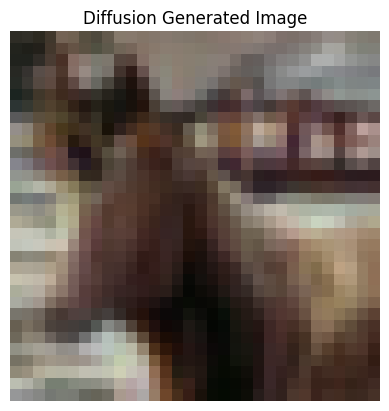

In [ ]:
from diffusers import DDPMPipeline

pipeline = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
pipeline = pipeline.to(device)

image = pipeline().images[0]

plt.imshow(image)
plt.title("Diffusion Generated Image")
plt.axis("off")
plt.show()